In [1]:
import matplotlib.pyplot as plt
import tifffile as tf
import cv2
import math as m
from skimage.measure import regionprops
import colorcet as cc
import numpy as np
from skimage.morphology import disk
import scipy.ndimage as ndi
import matplotlib.patches as patches
import skimage
# define qualitative colormap
glasbey = cc.cm.glasbey_dark_r

c:\Users\Hoellenmaschine2\anaconda3\lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been deprecated
  "class": algorithms.Blowfish,


In [2]:
preprocessed = cv2.imread(r"Fig2\Sample2_G1_225t(1848,3896,5544,7592)_preprocessed.png")
pred = cv2.imread(r"Fig2\Sample2_G1_225t(1848,3896,5544,7592)_predicted.png")
seg_inner = tf.imread(r"Fig2\Sample2_G1_225t.tif_inner_labeled.tif")
seg_outer = tf.imread(r"Fig2\Sample2_G1_225t.tif_outer_labeled.tif")
px_size = 4.3*4 # nominal px resolution [nanometer resolution] * downscaling factor 

In [3]:
# define region of the image to display
x_0 = 200
x_1 = 1000
y_0 = 100
y_1 = 900

x_c = 5544 # number of pixels to correct in x and y axis for fused prediction image
y_c  = 1848

x_0_c = x_0 + x_c # corrected x & y coordinates
x_1_c = x_1 + x_c
y_0_c = y_0 + y_c
y_1_c = y_1 + y_c

In [4]:
swm_preprocessed = cv2.imread(r"Fig2\Sample1_SWM_V1V2_Probe19_J1_Stitched(8192,16384,16384,24576).png")
swm_pred = cv2.imread(r"Fig2\Sample1_SWM_V1V2_Probe19_J1_Stitched(8192,16384,16384,24576)_predicted.png")
swm_seg_inner = tf.imread(r"Fig2\Sample1_SWM_V1V2_Probe19_J1_Stitched(8192,16384,16384,24576).png_inner_labeled.tif")
swm_seg_outer = tf.imread(r"Fig2\Sample1_SWM_V1V2_Probe19_J1_Stitched(8192,16384,16384,24576).png_outer_labeled.tif")

In [5]:
table = cv2.imread(r"Fig2\Fig2_table_larger.png")

In [6]:
# define region of the image to display
swm_x_0 = 625
swm_x_1 = 625+800
swm_y_0 = 735
swm_y_1 = 735+800

swm_x_c = 0 # number of pixels to correct in x and y axis for fused prediction image
swm_y_c  = 0

swm_x_0_c = swm_x_0 + swm_x_c # corrected x & y coordinates
swm_x_1_c = swm_x_1 + swm_x_c
swm_y_0_c = swm_y_0 + swm_y_c
swm_y_1_c = swm_y_1 + swm_y_c

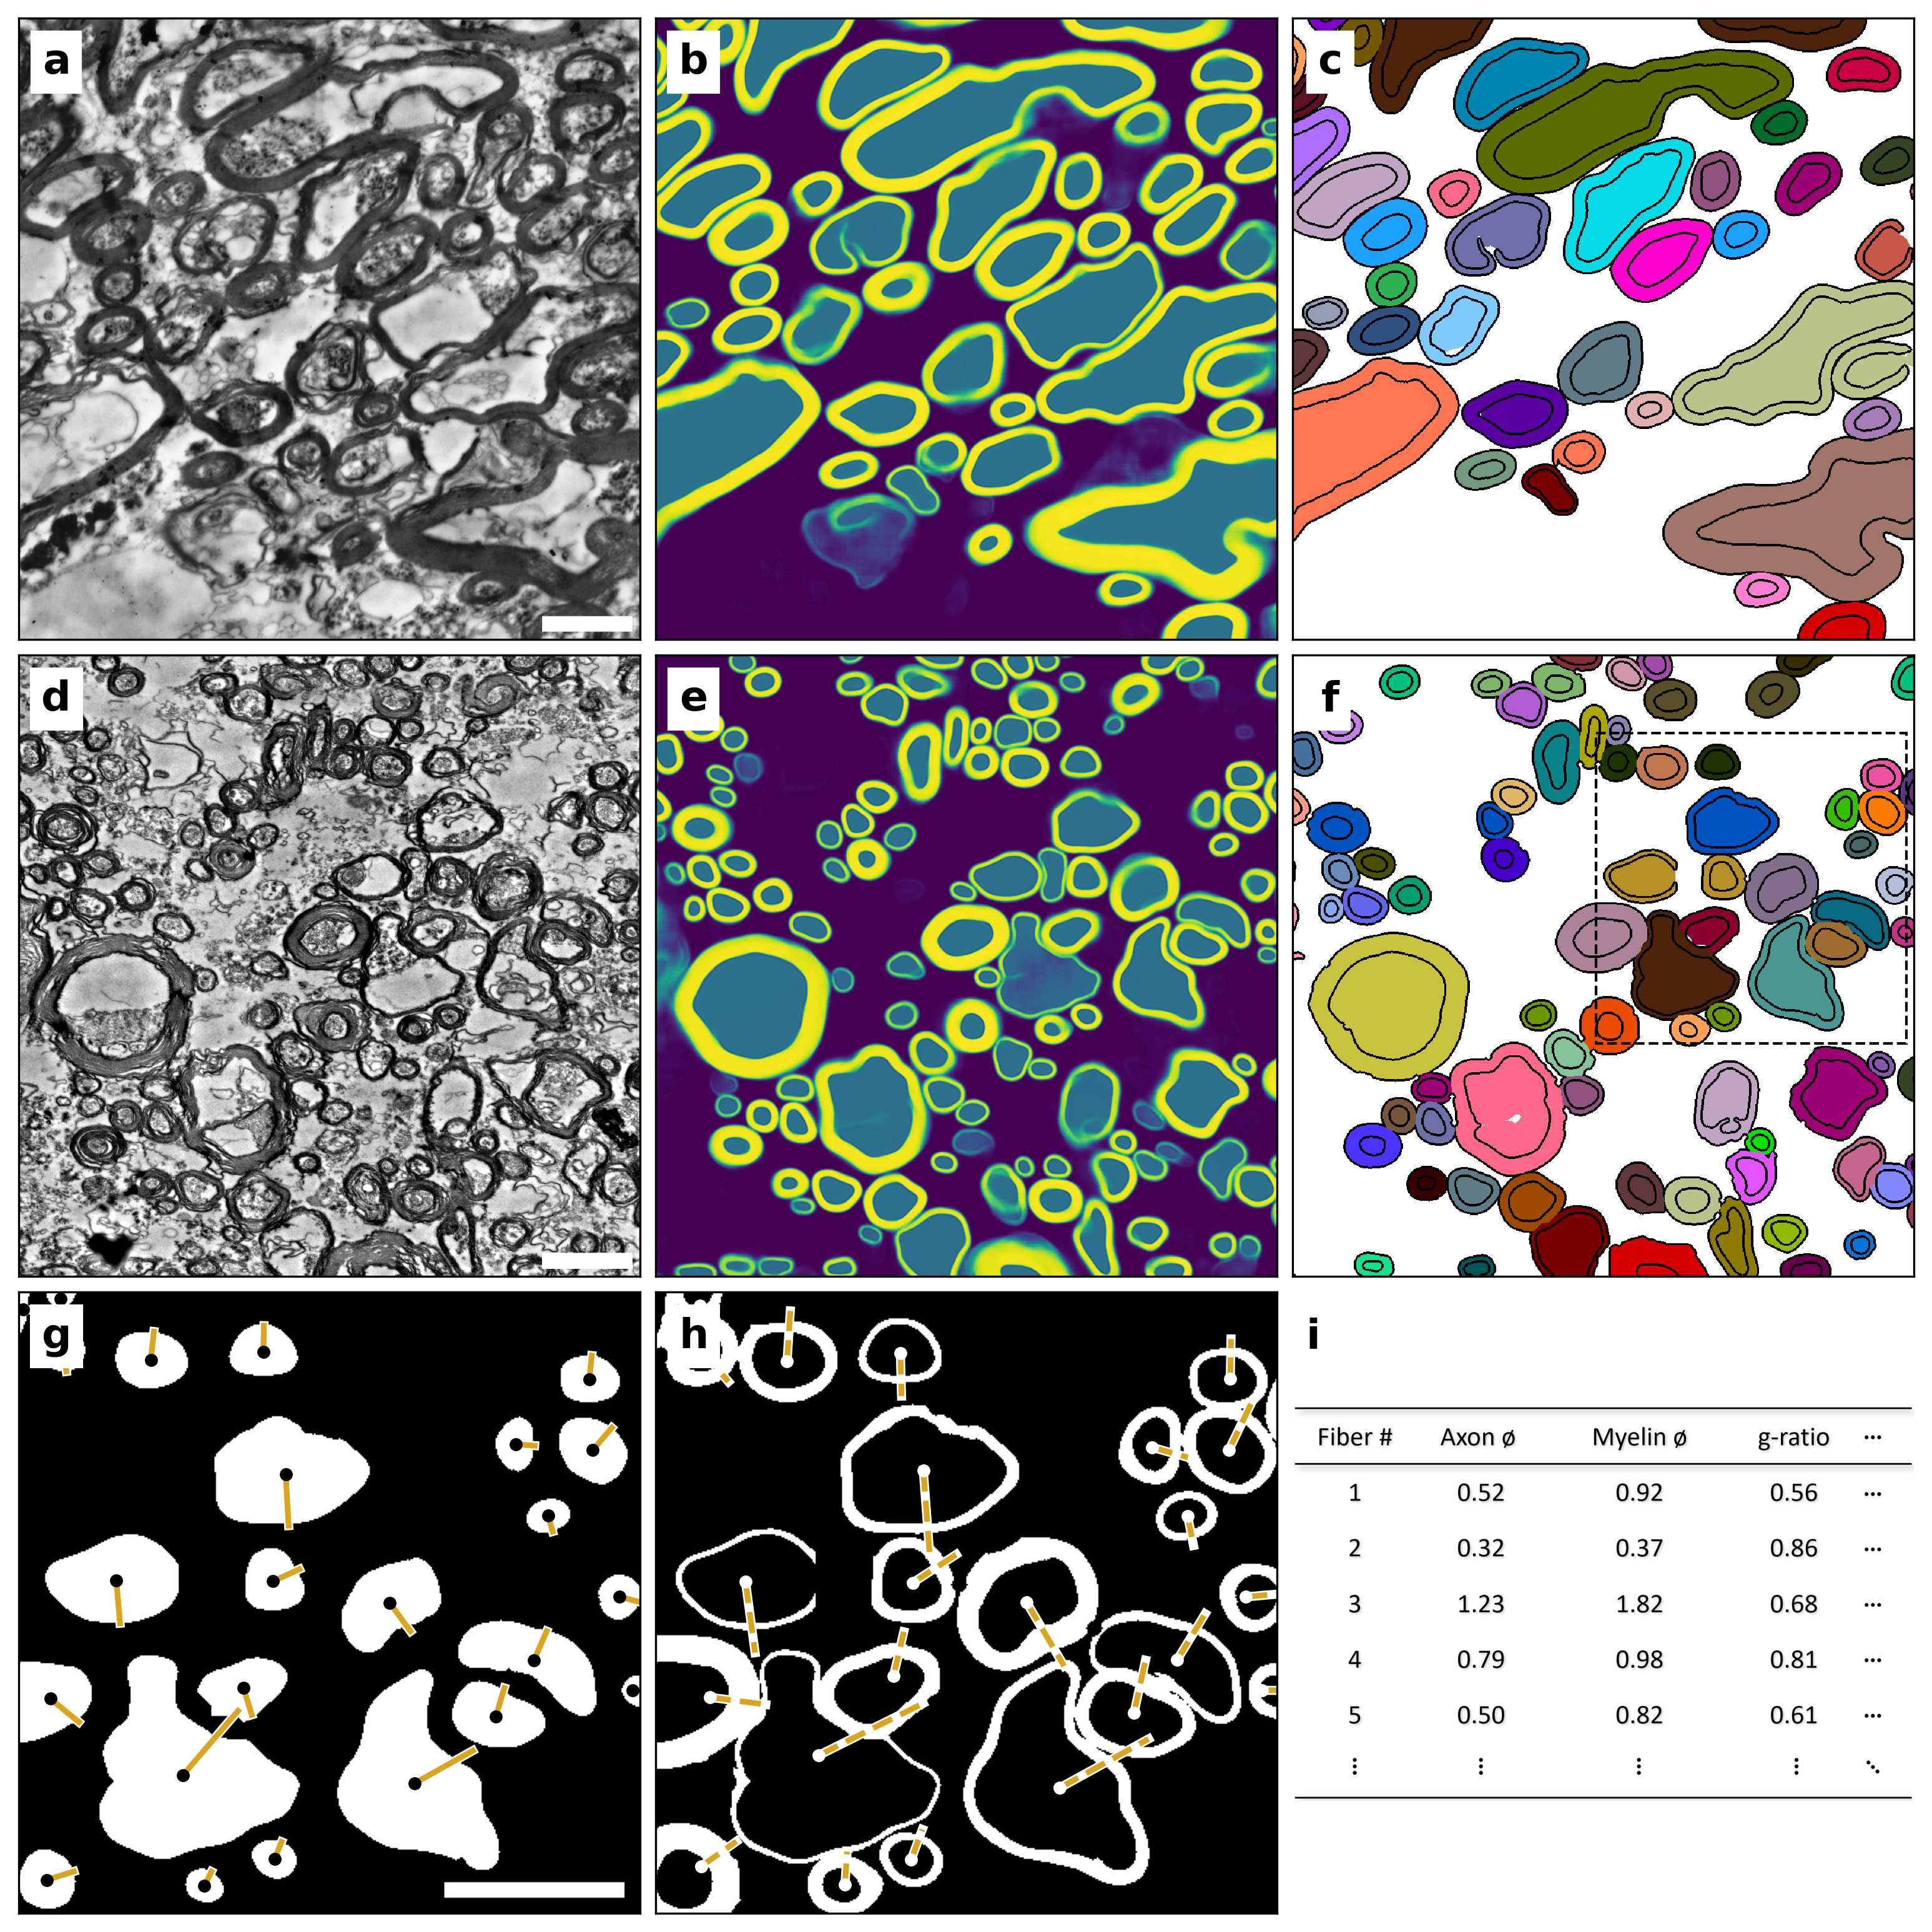

In [ ]:
txt_displace_x = 48
txt_displace_y = 56

# need to constrain segmentations by 100px on each axis so they are aligned
seg_inner = seg_inner[y_0_c-100:y_1_c-100,x_0_c-100:x_1_c-100]
seg_outer = seg_outer[y_0_c-100:y_1_c-100,x_0_c-100:x_1_c-100]
swm_seg_inner = swm_seg_inner[swm_y_0_c:swm_y_1_c,swm_x_0_c:swm_x_1_c]
swm_seg_outer = swm_seg_outer[swm_y_0_c:swm_y_1_c,swm_x_0_c:swm_x_1_c]

ax = plt.figure(layout="constrained",figsize=(10.2,10.2),dpi=300).subplot_mosaic(
    """
    aaabbbccc
    dddeeefff
    ggghhhiii
    """)

#A
###
img_a = preprocessed[y_0:y_1,x_0:x_1]
img_a[770:790,790-int(2000/px_size):790] = 255
ax["a"].imshow(img_a,vmax=255,vmin=0)

#B
###
ax["b"].imshow(pred[y_0:y_1,x_0:x_1,0],cmap='viridis')

#C
###
# generate instance segmentation picture
outer_dilated = ndi.binary_dilation(seg_outer,disk(3))
ero = np.logical_xor(seg_outer.astype('bool'),outer_dilated)
vmin = 2
vmax = seg_inner.max()
ax["c"].imshow(np.ma.array(seg_inner + seg_outer, mask=(seg_inner + seg_outer) == 0), cmap=glasbey,vmin=vmin,vmax=vmax,interpolation='None')
ax["c"].imshow(np.ma.array(ero, mask=(ero) == 0), interpolation='None', cmap='gray',)

image_shape = seg_inner.shape

#D
###
img_d = swm_preprocessed[swm_y_0:swm_y_1,swm_x_0:swm_x_1]

# burn-in scale bar of 2µm
img_d[770:790,790-int(2000/px_size):790] = 255
ax["d"].imshow(img_d[:,:,0],vmax=151,vmin=70,cmap='gray')

#E
###
ax["e"].imshow(swm_pred[swm_y_0:swm_y_1,swm_x_0:swm_x_1,0],cmap='viridis')

#F
###
# generate instance segmentation picture
swm_outer_dilated = ndi.binary_dilation(swm_seg_outer,disk(3))
ero = np.logical_xor(swm_seg_outer.astype('bool'),swm_outer_dilated)
vmin = 2
vmax = swm_seg_inner.max()
ax["f"].imshow(np.ma.array(swm_seg_inner + swm_seg_outer, mask=(swm_seg_inner + swm_seg_outer) == 0), cmap=glasbey,vmin=vmin,vmax=vmax,interpolation='None')
ax["f"].imshow(np.ma.array(ero, mask=(ero) == 0), interpolation='None', cmap='gray',)

# Add a dashed black square
rect = patches.Rectangle(
    (390, 100),  # bottom left corner
    400,  # width
    400,  # height
    linewidth=1, 
    edgecolor='black', 
    linestyle='--',
    facecolor='none'
)
ax["f"].add_patch(rect)

### crop from F
swm_seg_inner = swm_seg_inner[100:500,390:790]
swm_seg_outer = swm_seg_outer[100:500,390:790]

#G
###
regions = regionprops(swm_seg_inner)
for props in regions:
    y0, x0 = props.centroid
    orientation = props.orientation
    x1 = x0 + m.cos(orientation) * 0.5 * props.minor_axis_length
    y1 = y0 - m.sin(orientation) * 0.5 * props.minor_axis_length

    ax["g"].plot((x0, x1), (y0, y1), 'white', linewidth=3.5)
    ax["g"].plot((x0, x1), (y0, y1), 'goldenrod', linewidth=2.2)
    ax["g"].plot(x0, y0, '.k', markersize=8)

# burn-in scale bar of 2µm
swm_seg_inner[378:392,388-int(2000/px_size):392] = 0
swm_seg_inner[380:390,390-int(2000/px_size):390] = 255

ax["g"].imshow(swm_seg_inner.astype('bool'), cmap=plt.cm.gray)#,aspect=1)

#H
###
regions = regionprops(swm_seg_outer)
for props in regions:
    y0, x0 = props.centroid
    orientation = props.orientation
    x1 = x0 + m.cos(orientation) * 0.5 * props.minor_axis_length
    y1 = y0 - m.sin(orientation) * 0.5 * props.minor_axis_length

    ax["h"].plot((x0, x1), (y0, y1), 'white', linewidth=3.5,)
    ax["h"].plot((x0, x1), (y0, y1), 'goldenrod', linewidth=2.2, linestyle="--")
    ax["h"].plot(x0, y0, '.w', markersize=8)

ax["h"].imshow(swm_seg_outer.astype('bool'), cmap=plt.cm.gray)#,aspect=1)

for key in ax:
    ax[key].set_xticks([])
    ax[key].set_yticks([])
    ax[key].set_xticklabels([])
    ax[key].set_yticklabels([])
    
    # Adjust displacement for specific keys
    if key in ["g", "h"]:
        disp_x = txt_displace_x / 2
        disp_y = txt_displace_y / 2
    else:
        disp_x = txt_displace_x
        disp_y = txt_displace_y

    # Special case for key "i"
    if key == "i":
        ax[key].text(disp_x, disp_y - 216, key, color='black', ha='center', va='center', 
                     fontsize=16, backgroundcolor='white', weight='bold')
        continue

    ax[key].text(disp_x, disp_y, key, color='black', ha='center', va='center', 
                 fontsize=16, backgroundcolor='white', weight='bold')

#I
###
ax["i"].imshow(table)
ax["i"].set_frame_on(False)

plt.show()